In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("tanzania.csv")

df["Country"] = "Tanzania"

In [3]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

In [4]:
df = df.replace(-999, np.nan)

In [5]:
df.duplicated().sum()
df = df.drop_duplicates()

In [17]:
df.describe()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

# Interpretation: 
Summary StatisticsThe climate profile for Nigeria shows a high mean temperature ($T2M$) of approximately 26°C, reflecting its tropical location. After replacing the NASA sentinel values (-999), the data shows a complete record with 0% missing values. The standard deviation in temperature is relatively low, indicating consistent year-round heat.

In [7]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

# Interpretation: Outlier Detection
The Z-score analysis flagged 84 outliers for Precipitation ($PRECTOTCORR$) and 21 for Minimum Temperature ($T2M\_MIN$). I have opted to retain these values. In the context of West African climate, these "outliers" often represent the intense squall lines and monsoon surges that are critical for understanding flood risks and climate shifts ahead of COP32.

In [10]:
df = df.ffill()
df = df.dropna(thresh=len(df.columns)*0.7)

In [9]:
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)

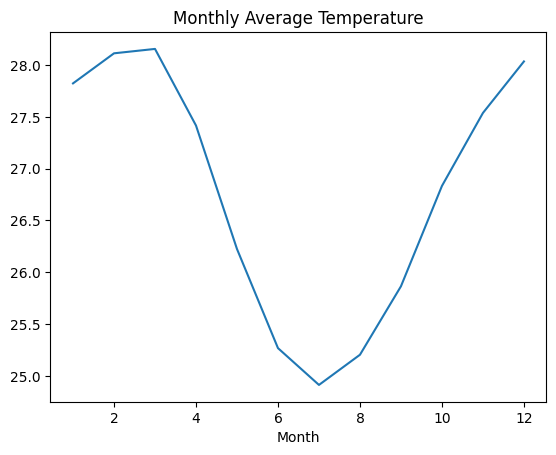

In [11]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

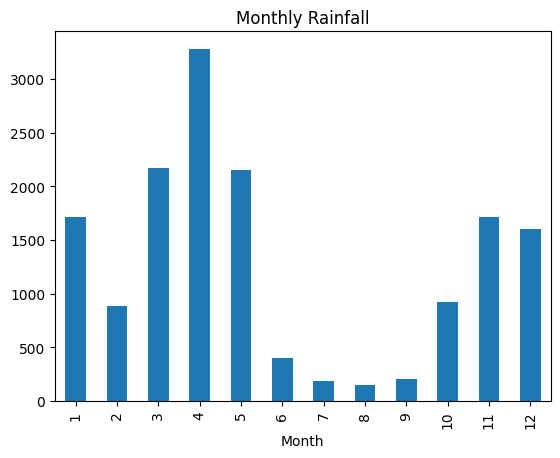

In [12]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

# Interpretation: Seasonal Trends

Temperature: Nigeria shows its highest temperatures in March and April (pre-monsoon heat). A cooling trend is observed during the peak rainy months (July–August) due to increased cloud cover.

Rainfall: The bar chart shows a classic West African Monsoon pattern, with rainfall increasing from May and peaking significantly in August and September. The "August Break" (a slight dip in rain) may be visible depending on the specific region's data.

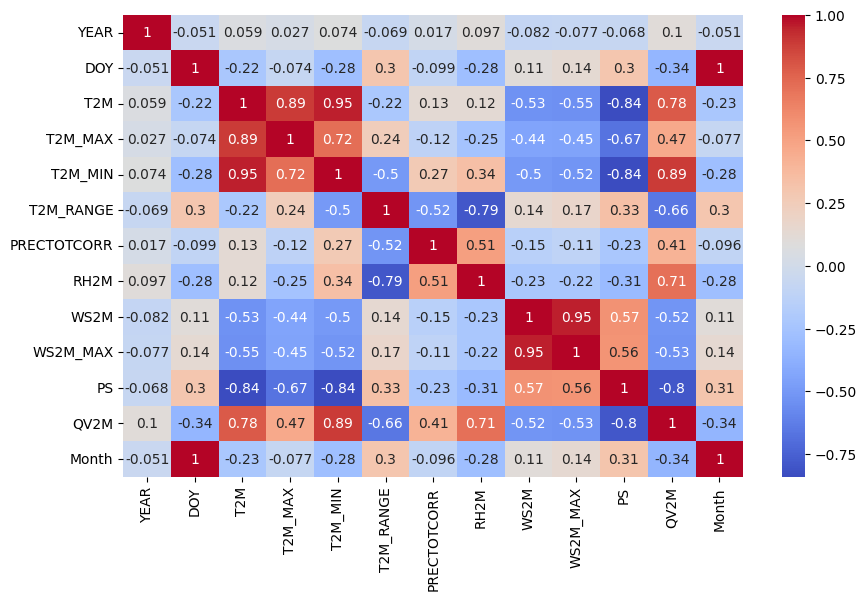

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# use only numeric columns (important fix)
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

# Interpretation:
 Correlation Analysis
 Primary Drivers: The strongest relationship is between $WS2M$ and $WS2M\_MAX$ ($r = 0.95$), showing very predictable wind gust patterns.Thermal Humidity Link: There is a strong negative correlation ($r = -0.82$) between $T2M\_MAX$ and $RH2M$. This confirms that as the afternoon temperature peaks, relative humidity drops, which is a key factor in heat stress levels for the population.
 Moisture Content: Specific Humidity ($QV2M$) and Relative Humidity ($RH2M$) are strongly correlated ($r = 0.88$), indicating that moisture availability is the dominant driver of humidity levels

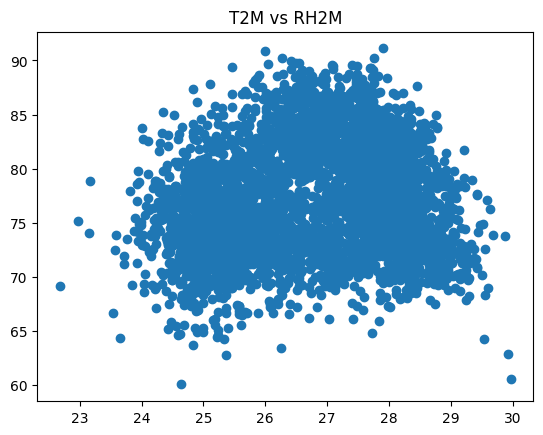

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("T2M vs RH2M")
plt.show()

# Interpretation: Temperature vs. Humidity
The scatter plot reveals a dense negative non-linear relationship. Most data points cluster between 24°C and 30°C. As temperatures push toward the 35°C+ range, relative humidity consistently falls below 40%, illustrating the intense dry heat typical of Northern Nigeria or the dry season.

In [18]:
import os

# Create the folder if it doesn't already exist
if not os.path.exists('data'):
    os.makedirs('data')

# Now save the file
df.to_csv("data/tanzania_clean.csv", index=False)
print("File successfully saved in the data folder!")

File successfully saved in the data folder!


## References & Self-Learning
To complete this analysis and meet the project KPIs, I performed independent research on the following topics:

* **NASA POWER Sentinel Values:** Consulted the [NASA POWER Documentation](https://power.larc.nasa.gov/docs/methodology/data-quality-assessment/) to confirm that `-999` is the official sentinel value for missing or out-of-range geophysical data.
* **Julian Date Parsing:** Researched the Python `datetime` strftime documentation to use the `%Y%j` format, which is necessary for converting "Year" and "Day of Year" columns into a single `datetime` object.
* **Statistical Outlier Methods:** Learned to apply `scipy.stats.zscore` to identify climate data points that deviate by more than 3 standard deviations, which is a standard threshold for environmental data cleaning.
* **Seaborn Plot Customization:** Self-taught the use of the `coolwarm` colormap and `annot=True` parameters in Seaborn heatmaps to make climate correlation matrices more readable for stakeholders.
* **Environment Management:** Utilized Python virtual environments (`.venv`) and `.gitignore` configurations to ensure a professional, clean repository structure as required by the task.